# Análise de Clusterização dos Municípios Paulistas

In [158]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

### 1. Leitura do Dataset

In [159]:
df = pd.read_csv(
    "data/processed/main_dataframe.csv",
    sep=";"
)

### 2. Variáveis utilizadas na clusterização

Foram utilizadas três variáveis:

- IDS
- Receita anual
- População

Essas variáveis representam simultaneamente aspectos de desenvolvimento em saúde, capacidade econômica e porte populacional dos municípios.

In [160]:
FEATURES = [
    "ids",
    "receita_anual",
    "populacao"
]

X = df[FEATURES].copy()

### 3. Clusterização considerando todos os municípios

Primeiramente será realizada a clusterização utilizando todos os
municípios do estado, incluindo a capital paulista.

In [161]:
X = df[FEATURES].copy()

### 4. Normalização

Como as variáveis possuem escalas muito diferentes, foi aplicada a padronização utilizando StandardScaler.

In [162]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### 5. Aplicação do K-Means (4 clusters)

In [163]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
    
)

df["cluster"] = kmeans.fit_predict(X_scaled)

### 6. Avaliação dos agrupamentos

A qualidade dos clusters foi avaliada utilizando o Silhouette Score.

Valores próximos de 1 indicam grupos bem separados. Valores próximos de 0 indicam sobreposição entre clusters.

In [164]:
silhouette = silhouette_score(
    X_scaled,
    df["cluster"]
)

print(f"Silhouette Score: {silhouette:.4f}")

Silhouette Score: 0.4842


### 7. Perfil estatístico dos clusters

In [165]:
profile = (
    df.groupby("cluster")[FEATURES]
    .agg(["mean", "median", "min", "max"])
    .round(2)
)

profile

ids                    receita_anual                              \
         mean median   min   max          mean        median           min   
cluster                                                                      
0        0.73   0.71  0.62  0.97  6.092459e+08  2.122639e+08  2.499808e+07   
1        0.74   0.74  0.74  0.74  9.578991e+10  9.578991e+10  9.578991e+10   
2        0.32   0.33  0.13  0.45  1.697973e+08  5.069474e+07  1.361518e+06   
3        0.57   0.58  0.45  0.66  1.736573e+08  6.949144e+07  1.443219e+07   

                         populacao                                  
                  max         mean      median       min       max  
cluster                                                             
0        8.143600e+09     89543.18     33847.5      1290   1223237  
1        9.578991e+10  12396372.00  12396372.0  12396372  12396372  
2        6.192621e+09     38576.96      7905.0       839   1404694  
3        2.379475e+09     32737.46     12639.0      1142    455587

### 8. Quantidade de municípios por Cluster

In [166]:
df["cluster"] \
    .value_counts() \
    .sort_index()

cluster
0    212
1      1
2    193
3    239
Name: count, dtype: int64

In [167]:
cluster = 0
dados = (
    df[
        df["cluster"] == cluster
    ]
    .sort_values(
        by=["ids", "receita_anual"],
        ascending=False
    )
)

dados[
    [
        "municipio",
        "ids",
        "receita_anual",
        "populacao"
    ]
].head(10)

,municipio,ids,receita_anual,populacao
545,SAO CAETANO DO SUL,0.966,2.042468e+09,162763
636,VINHEDO,0.924,8.123369e+08,81516
542,SANTOS,0.912,4.284191e+09,433991
293,JUNDIAI,0.894,3.664002e+09,426935
234,ILHA SOLTEIRA,0.875,2.346250e+08,26886
521,SANTA FE DO SUL,0.873,2.948873e+08,32796
0,ADAMANTINA,0.872,2.688760e+08,35153
302,LENCOIS PAULISTA,0.864,4.798066e+08,69533
548,SAO JOAO DA BOA VISTA,0.852,5.967856e+08,92315
629,VALINHOS,0.851,9.722731e+08,133169


### 9. Representação gráfica

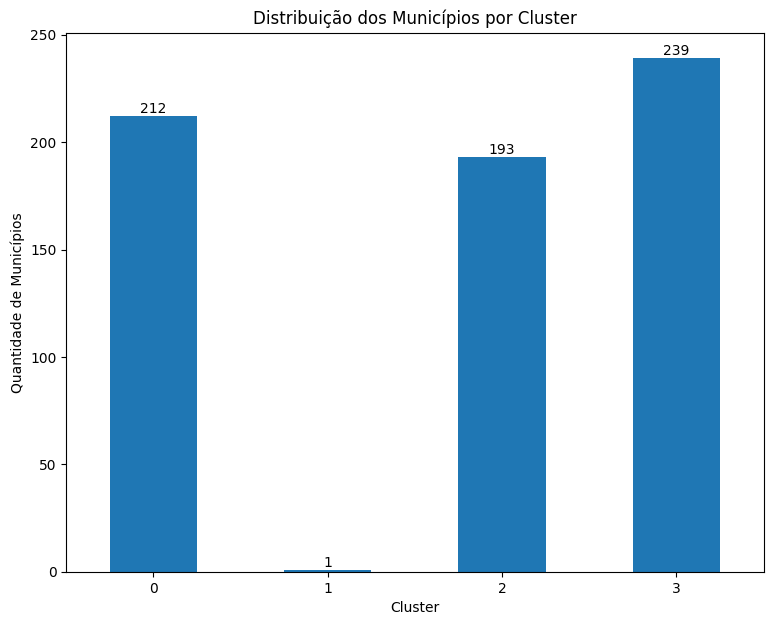

In [168]:
plt.figure(figsize=(9,7))

ax = (
    df["cluster"]
    .value_counts()
    .sort_index()
    .plot(kind="bar")
)

plt.title("Distribuição dos Municípios por Cluster")
plt.xlabel("Cluster")
plt.ylabel("Quantidade de Municípios")
plt.xticks(rotation=0)

for barra in ax.patches:
    altura = barra.get_height()

    ax.annotate(
        f"{int(altura)}",
        (
            barra.get_x() + barra.get_width()/2,
            altura
        ),
        ha="center",
        va="bottom"
    )

plt.show()

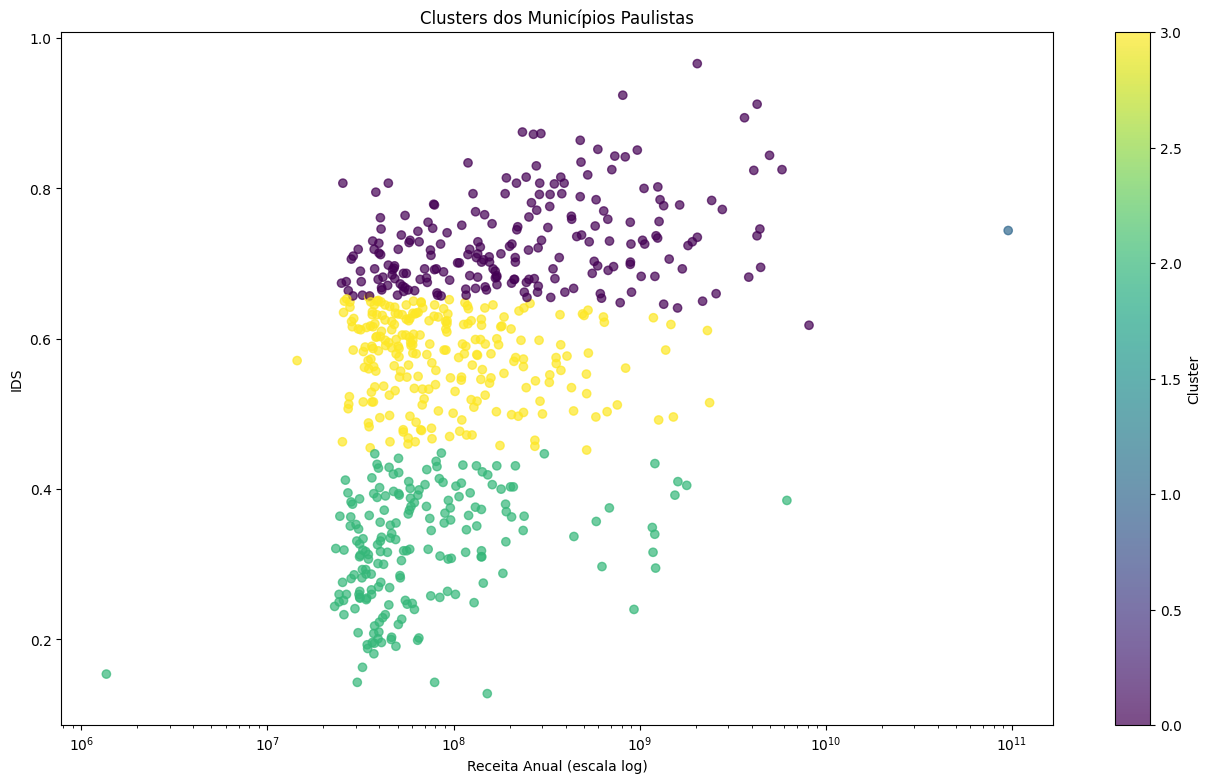

In [169]:
plt.figure(figsize=(16,9))

scatter = plt.scatter(
    df["receita_anual"],
    df["ids"],
    c=df["cluster"],
    alpha=0.7
)

plt.xscale("log")

plt.title("Clusters dos Municípios Paulistas")
plt.xlabel("Receita Anual (escala log)")
plt.ylabel("IDS")
plt.colorbar(scatter, label="Cluster")

plt.show()

## Conclusão Intermediária:

Ao realizar a clusterização com todos os municípios do estado de São Paulo, observou-se a formação de um cluster composto por apenas um município, caracterizado por valores extremamente superiores de população e receita anual em relação aos demais.

Esse comportamento evidencia a presença de um outlier no conjunto de dados, correspondente ao município de São Paulo. Sua magnitude demográfica e econômica faz com que o algoritmo o isole em um cluster próprio, reduzindo a capacidade de identificação de padrões entre os demais municípios.

Assim, será realizada uma segunda etapa de clusterização sem a inclusão de São Paulo, a fim de obter grupos mais interpretáveis.


## Parte 2 do experimento: Remoção do município de São Paulo

In [170]:
df_without_sp = df[
    df["municipio"] != "SAO PAULO"
].copy()

### Normalização

In [171]:
X = df_without_sp[FEATURES]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

### Aplicação do K-Means

In [172]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df_without_sp["cluster"] = kmeans.fit_predict(
    X_scaled
)

### Avaliação do Silhouette Score

Observar a diferença entre esse score e o anterior (espera-se que esse seja maior).

In [175]:
silhouette = silhouette_score(
    X_scaled,
    df_without_sp["cluster"]
)

print(
    f"Silhouette Score: {silhouette:.4f}"
)

Silhouette Score: 0.5644


### 7. Perfil estatístico dos clusters

In [176]:
profile = (
    df_without_sp
    .groupby("cluster")[FEATURES]
    .agg([
        "mean",
        "median",
        "min",
        "max"
    ])
    .round(2)
)

profile

ids                    receita_anual                              \
         mean median   min   max          mean        median           min   
cluster                                                                      
0        0.65   0.65  0.50  0.92  1.833916e+08  9.408158e+07  1.443219e+07   
1        0.61   0.65  0.24  0.97  1.503557e+09  1.347853e+09  7.592513e+08   
2        0.74   0.75  0.38  0.91  4.933553e+09  4.433108e+09  3.664002e+09   
3        0.34   0.35  0.13  0.50  8.316483e+07  5.091069e+07  1.361518e+06   

                       populacao                             
                  max       mean    median     min      max  
cluster                                                      
0        1.288563e+09   30042.05   15799.5    1142   158438  
1        2.784507e+09  272593.41  256915.0  114508   481725  
2        8.143600e+09  745136.91  720116.0  279704  1404694  
3        6.880922e+08   16208.86    7883.5     839   198661

### 8. Quantidade de municípios por cluster

In [180]:
df_without_sp["cluster"] \
    .value_counts() \
    .sort_index()

cluster
0    382
1     41
2     11
3    210
Name: count, dtype: int64

In [181]:
cluster = 0
dados = (
    df[
        df["cluster"] == cluster
    ]
    .sort_values(
        by=["ids", "receita_anual"],
        ascending=False
    )
)

dados[
    [
        "municipio",
        "ids",
        "receita_anual",
        "populacao"
    ]
].head(10)

,municipio,ids,receita_anual,populacao
545,SAO CAETANO DO SUL,0.966,2.042468e+09,162763
636,VINHEDO,0.924,8.123369e+08,81516
542,SANTOS,0.912,4.284191e+09,433991
293,JUNDIAI,0.894,3.664002e+09,426935
234,ILHA SOLTEIRA,0.875,2.346250e+08,26886
521,SANTA FE DO SUL,0.873,2.948873e+08,32796
0,ADAMANTINA,0.872,2.688760e+08,35153
302,LENCOIS PAULISTA,0.864,4.798066e+08,69533
548,SAO JOAO DA BOA VISTA,0.852,5.967856e+08,92315
629,VALINHOS,0.851,9.722731e+08,133169


### 10. Gráfico de distribuição dos municípios por cluster

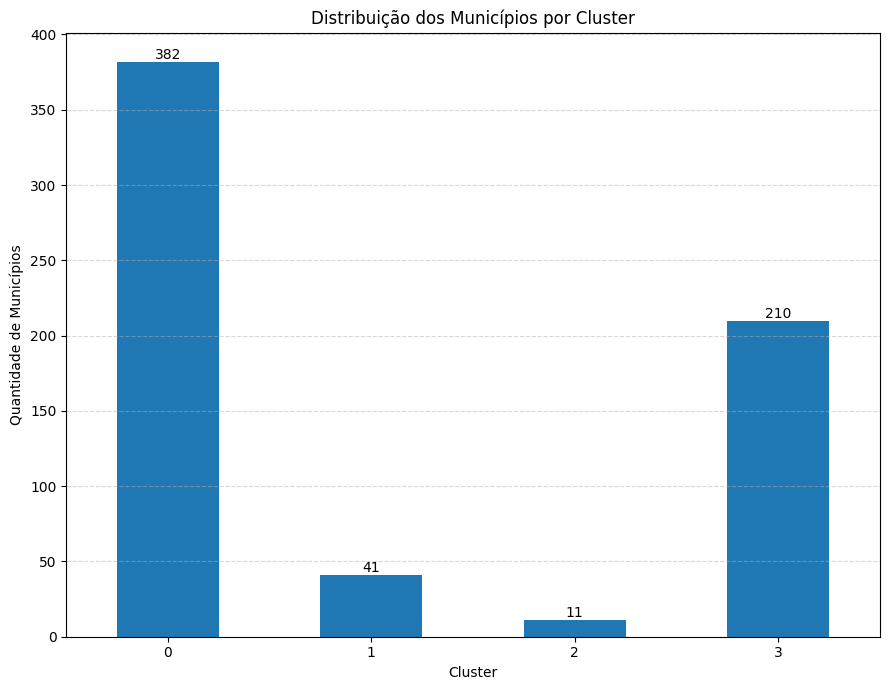

In [182]:
plt.figure(figsize=(9, 7))

ax = (
    df_without_sp["cluster"]
    .value_counts()
    .sort_index()
    .plot(kind="bar")
)

plt.title("Distribuição dos Municípios por Cluster")
plt.xlabel("Cluster")
plt.ylabel("Quantidade de Municípios")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.5)

for barra in ax.patches:
    altura = barra.get_height()

    ax.annotate(
        f"{int(altura)}",
        (
            barra.get_x() + barra.get_width() / 2,
            altura
        ),
        ha="center",
        va="bottom",
        fontsize=10
    )
    
plt.tight_layout()
plt.show()

### 11. Scatterplot

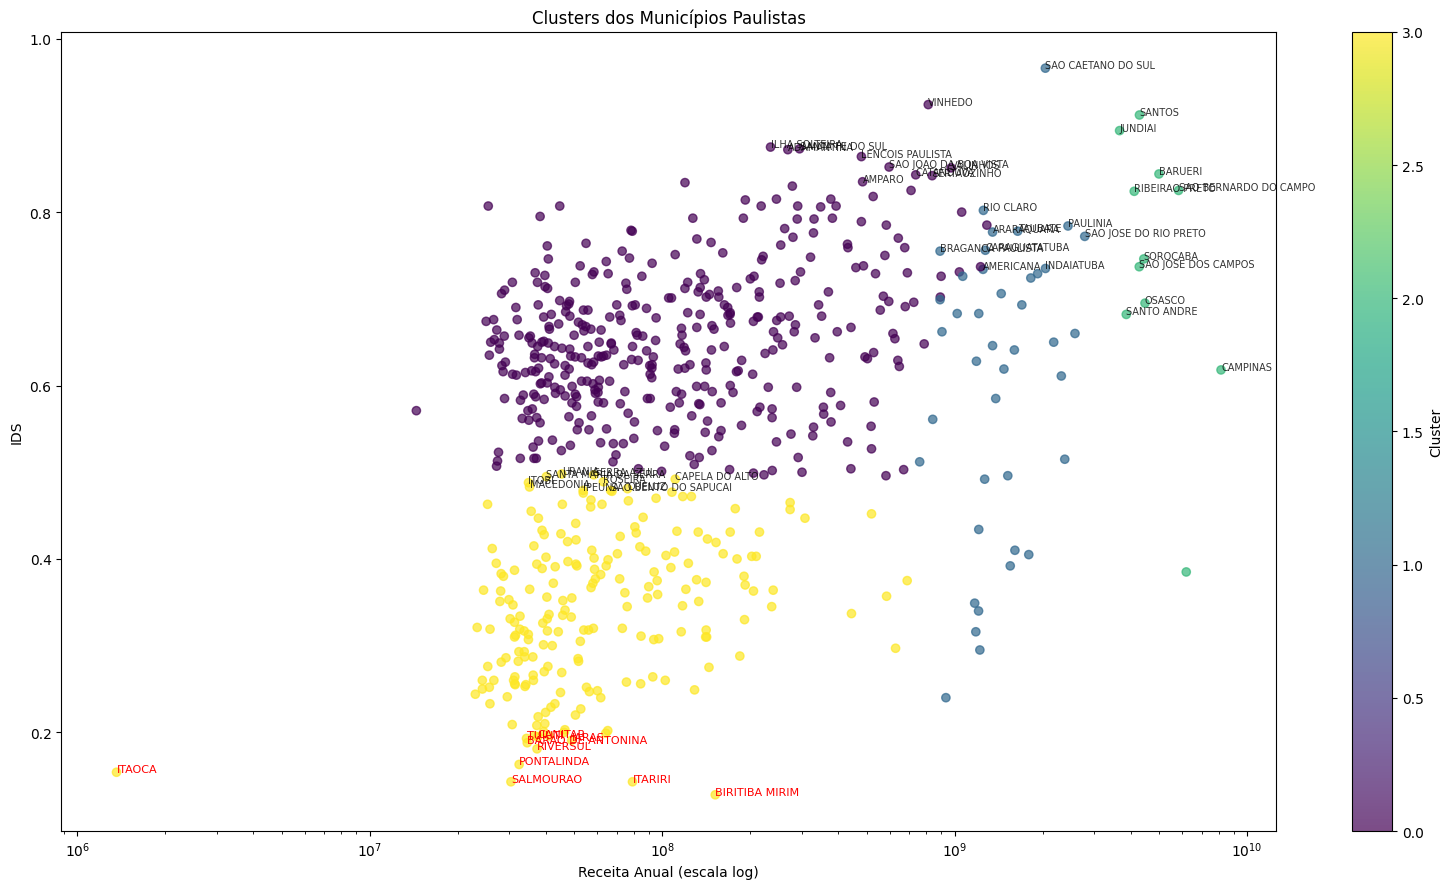

In [183]:
plt.figure(figsize=(16, 9))

scatter = plt.scatter(
    df_without_sp["receita_anual"],
    df_without_sp["ids"],
    c=df_without_sp["cluster"],
    alpha=0.7
)

plt.xscale("log")

# Mostrar os 10 melhores municípios de cada cluster
for cluster in sorted(df_without_sp["cluster"].unique()):

    top10 = (
        df_without_sp[df_without_sp["cluster"] == cluster]
        .nlargest(10, "ids")
    )

    for _, row in top10.iterrows():
        plt.annotate(
            row["municipio"],
            (row["receita_anual"], row["ids"]),
            fontsize=7,
            alpha=0.8
        )

# Mostrar os 10 piores IDS do estado inteiro
bottom10 = (
    df_without_sp
    .nsmallest(10, "ids")
)

for _, row in bottom10.iterrows():
    plt.annotate(
        row["municipio"],
        (row["receita_anual"], row["ids"]),
        fontsize=8,
        color="red"
    )

plt.title("Clusters dos Municípios Paulistas")
plt.xlabel("Receita Anual (escala log)")
plt.ylabel("IDS")
plt.colorbar(scatter, label="Cluster")

plt.tight_layout()
plt.show()

## Conclusões

Após análise dos resultados podemos perceber os seguintes padrões:


Cluster 3 (Amarelo):

* 210 municípios;
* IDS médio: 0,34;
* Receita média: R$ 83 milhões;
* População média: 16 mil habitantes;
* Cluster com Alta Vulnerabilidade Estrutural.

Cluster 0 (Roxo):

* 382 municípios;
* IDS médio: 0,65;
* Receita média: R$ 183 milhões;
* População média: 30 mil habitantes;
* Cluster com Média Vulnerabilidade Estrutural.

Cluster 1 (Azul):

* 41 municípios;
* IDS médio: 0,61;
* Receita média: R$ 1,5 bilhão;
* População média: 272 mil habitantes;
* Cluster com Vulnerabilidade Estrutural Média-Alta.

Cluster 2 (Verde):

* 11 municípios;
* IDS médio: 0,74;
* Receita média: R$ 4,9 bilhões;
* População média: 745 mil habitantes;
* Cluster com Vulnerabilidade Estrutural Baixa.